# `orbital-game` — 3D RTN workflow walkthrough

Full-3D relative motion: `RTNState` per vehicle (radial / along-track / cross-track) under HCW-RTN dynamics. The guard carries `Mass` so propellant depletes over the rollout.

Steps covered:

1. Build a `ScenarioConfig` for HCW-RTN dynamics
2. Construct an `OrbitalGameEnv` from the config
3. Define a simple guard policy + null policy-state initializer
4. Run two `rollout`s with different seeds
5. Visualize relative motion (R-T, R-N, T-N projections + 3D RTN view)
6. Plot reward curves and propellant-mass curves
7. Save and reload one rollout via HDF5

**Setup.** Run with `uv` (Jupyter is not in the project deps; the easiest way is):

```bash
uv run --with jupyter --with ipykernel jupyter notebook examples/workflow_3d_rtn.ipynb
```

For the 2D (in-plane) variant of this same workflow, see `workflow_2d_rt.ipynb`.

In [1]:
# Requires the project's dev extras (in particular ipywidgets, used by
# interactive_viewer below). If you haven't already, run from the repo root:
#     uv sync --extra dev
# and then restart this kernel.

# Auto-reload edited library code without a kernel restart. Run this cell
# again after editing any orbital_game module to pick up the changes.
%load_ext autoreload
%autoreload 2

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
from types import SimpleNamespace

from orbital_game import OrbitalGameEnv, ScenarioConfig, VehicleParamsSpec, rollout, save_run, load_run
from orbital_game.belief import (
    BeliefRollout,
    EKFBeliefUpdater,
    EKFUniformDefaultInitializer,
    run_belief_rollout,
)
from orbital_game.dynamics.hcw import hcw_rtn_step
from orbital_game.env.types import BySide, Side
from orbital_game.observations.range_limited import RangeLimitedObservation
from orbital_game.policies.library import ZeroControl
from orbital_game.reference_orbit import ReferenceOrbitState, mean_motion as ref_mean_motion
from orbital_game.registry import DynamicsKey, StateComponentKey
from orbital_game.sampling.spec import ICSpec
from orbital_game.sampling.side import RelativeEllipse
from orbital_game.sampling.mass import ConstantMass
from orbital_game.viz import (
    RolloutScene,
    interactive_viewer,
    plot_reward_curve,
    plot_reward_diagnostic,
    plot_rollout_mass,
    plot_rollout_panels,
    plot_rollout_rewards,
    plot_rn,
    plot_rt,
    plot_rtn_3d,
    plot_tn,
    save_animation,
)


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## 1. Build a 3D RTN scenario

`ScenarioConfig` is a frozen dataclass that describes everything about a scenario.
We pick a small scenario: 1 guard (with `Mass` so propellant depletes) + 1 bandit, HCW-RTN dynamics (the default), impulsive actuator (also default), each on a 1 km bounded relative orbit with opposite phase.

The IC sampler is `RelativeEllipse`, parameterized by physical ellipse extents in meters: `radial_ellipse_m` is the in-plane semi-major axis, `cross_track_m` is the out-of-plane amplitude, and `phase_rad` controls where on the relative orbit the vehicle sits at t=0. With `delta_a=0` (default), the resulting orbit is bounded — the vehicle stays near the reference orbit forever, unlike a naive Gaussian on raw RTN state which would drift.

In [2]:
# RangeLimitedObservation needs the layout, so we build a prototype env from a
# placeholder cfg first, capture its layout, then build the real cfg with the
# observation fns wired in. (The first cfg is discarded; only its layout is
# reused, since layouts are determined entirely by side composition + sizes.)
proto_cfg = ScenarioConfig(
    n_guards=1,
    n_bandits=1,
    epoch_mjd_utc=60067.0,
    reference_orbit=ReferenceOrbitState(
        position_eci=jnp.array([7000e3, 0.0, 0.0]),
        velocity_eci=jnp.array([0.0, 7.5e3, 0.0]),
    ),
    guard_components=(StateComponentKey.RTN, StateComponentKey.MASS),
    bandit_components=(StateComponentKey.RTN,),
    guard_params=VehicleParamsSpec(dry_mass_kg=100.0, isp_s=220.0, max_thrust_n=5.0),
    bandit_params=VehicleParamsSpec(dry_mass_kg=50.0, isp_s=200.0, max_thrust_n=2.0),
    ic_sampler=ICSpec(
        guard_sampler=RelativeEllipse(
            radial_ellipse_m=1000.0, phase_rad=0.0, sigma_radial_ellipse_m=10.0,
            mass_sampler=ConstantMass(propellant_mass_kg=10.0),
        ),
        bandit_sampler=RelativeEllipse(
            radial_ellipse_m=1000.0, phase_rad=jnp.pi, sigma_radial_ellipse_m=10.0,
        ),
    ),
    truth_dynamics=DynamicsKey.HCW_RTN,
    planning_dynamics=DynamicsKey.HCW_RTN,
    dt=10.0,
    max_horizon_s=6000.0,
    seed=0,
)
proto_layout = OrbitalGameEnv(proto_cfg).layout

# Sensor range chosen so the bandit drifts in and out of view across the orbit.
SENSOR_RANGE_M = 2500.0
guard_obs_fn = RangeLimitedObservation(layout=proto_layout, sensor_range_m=SENSOR_RANGE_M, sigma_range=5.0)
bandit_obs_fn = RangeLimitedObservation(layout=proto_layout, sensor_range_m=SENSOR_RANGE_M, sigma_range=5.0)

cfg = ScenarioConfig(
    n_guards=1,
    n_bandits=1,
    epoch_mjd_utc=60067.0,
    reference_orbit=ReferenceOrbitState(
        position_eci=jnp.array([7000e3, 0.0, 0.0]),
        velocity_eci=jnp.array([0.0, 7.5e3, 0.0]),
    ),
    guard_components=(StateComponentKey.RTN, StateComponentKey.MASS),
    bandit_components=(StateComponentKey.RTN,),
    guard_params=VehicleParamsSpec(dry_mass_kg=100.0, isp_s=220.0, max_thrust_n=5.0),
    bandit_params=VehicleParamsSpec(dry_mass_kg=50.0, isp_s=200.0, max_thrust_n=2.0),
    ic_sampler=ICSpec(
        guard_sampler=RelativeEllipse(
            radial_ellipse_m=1000.0, phase_rad=0.0, sigma_radial_ellipse_m=10.0,
            mass_sampler=ConstantMass(propellant_mass_kg=10.0),
        ),
        bandit_sampler=RelativeEllipse(
            radial_ellipse_m=1000.0, phase_rad=jnp.pi, sigma_radial_ellipse_m=10.0,
        ),
    ),
    truth_dynamics=DynamicsKey.HCW_RTN,
    planning_dynamics=DynamicsKey.HCW_RTN,
    guard_observation_fn=guard_obs_fn,
    bandit_observation_fn=bandit_obs_fn,
    dt=10.0,
    max_horizon_s=6000.0,
    seed=0,
)

print(f"max_steps (derived):  {cfg.max_steps}")
print(f"sensor range (m):     {SENSOR_RANGE_M}")
print(f"guard obs fn:         {type(cfg.guard_observation_fn).__name__}")
print(f"bandit obs fn:        {type(cfg.bandit_observation_fn).__name__}")


max_steps (derived):  600
sensor range (m):     2500.0
guard obs fn:         RangeLimitedObservation
bandit obs fn:        RangeLimitedObservation


## 2. Construct the environment

`OrbitalGameEnv(cfg)` resolves all pluggables, assembles per-scenario state classes, builds the `StateLayout`, computes mean motion from the reference orbit orbit, and stores the IC sampler. It exposes `reset(key)` and `step(key, state, action)` as pure functions.

In [3]:
env = OrbitalGameEnv(cfg)
print(f"mean motion (rad/s): {env.mean_motion:.3e}")
print(f"layout flat dim:     {env.layout.flat_dim}")  # 6 RTN + 1 mass + 6 bandit RTN = 13

mean motion (rad/s): 1.098e-03
layout flat dim:     13


## 3. Define a policy and run two rollouts

The default policy commands zero Δv each step — the guard takes no maneuvers, so the rollout shows **pure HCW dynamics** evolving from the sampled IC. Because the IC sits on a bounded relative orbit (`RelativeEllipse` with `delta_a=0`), you should see a closed 2:1 ellipse in the R-T plane: the guard oscillates between `±radial_ellipse_m` radially and `±2·radial_ellipse_m` along-track, completing one full loop per orbital period. The horizon is set to ~1 orbit so this loop is visible end-to-end.

A commented-out alternative gives the guard small random Gaussian impulses each step — switch to it if you want to see propellant depletion in section 6 (and watch the bounded orbit get nudged).

`init_ps` returns `None` — we don't track belief in this demo. Action shape is `(N_guards, 3)` for HCW-RTN.

In [4]:
# Default policy: zero-control — no maneuvers, pure HCW dynamics.
# Action shape is (N_guards, 3) for HCW-RTN.
guard_policy = ZeroControl(n_vehicles=cfg.n_guards, action_dim=3)
bandit_policy = ZeroControl(n_vehicles=cfg.n_bandits, action_dim=3)

# Alternative: small random Gaussian impulses each step (m/s). Uncomment to
# enable; the guard will perturb its trajectory and visibly deplete
# propellant. Action shape is (N_guards, 3) for HCW-RTN.
# def guard_policy_fn(policy_state, obs, key, t):
#     del obs, t
#     return jax.random.normal(key, (cfg.n_guards, 3)) * 0.5, policy_state
# guard_policy = guard_policy_fn

def init_ps(config, env_state, key):
    del config, env_state, key
    return None

key1, key2 = jax.random.split(jax.random.PRNGKey(42), 2)
traj1 = rollout(env, BySide(guard=guard_policy, bandit=bandit_policy),
                BySide(guard=init_ps, bandit=init_ps), key1, n_steps=cfg.max_steps)
traj2 = rollout(env, BySide(guard=guard_policy, bandit=bandit_policy),
                BySide(guard=init_ps, bandit=init_ps), key2, n_steps=cfg.max_steps)

print(f"rollout 1 episode return:  {float(traj1.sides.guard.reward.sum()):.2f}")
print(f"rollout 2 episode return:  {float(traj2.sides.guard.reward.sum()):.2f}")
print(f"rollout 1 first guard RTN pos: {traj1.env_state.guards.rtn[0, 0, :3]}")
print(f"rollout 2 first guard RTN pos: {traj2.env_state.guards.rtn[0, 0, :3]}")

rollout 1 episode return:  -923526.54
rollout 2 episode return:  -916806.50
rollout 1 first guard RTN pos: [-1013.22705333     0.             0.        ]
rollout 2 first guard RTN pos: [-1005.85431115     0.             0.        ]


## 3b. Partial observability + EKF belief

Beyond pure dynamics, the framework lets each side use its own
**observation function** (any sensor model satisfying the `ObservationFn`
protocol) and its own **belief representation** (any updater satisfying
`BeliefUpdater`). Here we attach a `RangeLimitedObservation` to both sides
— each observer measures the position of every opposing vehicle that is
within `sensor_range_m` (otherwise the visibility mask zeroes the
measurement). On top of that we wire an **EKF belief** that propagates
each tracked target's mean and covariance under HCW dynamics and corrects
on the gated, noisy position measurements. `run_belief_rollout` runs both
the env step and the belief update inside a single `jax.lax.scan`, so the
returned `belief_history` has a leading time axis ready to be visualized.


In [5]:
# Per-vehicle dynamics adapter: hcw_rtn_step is batched over (n, d); the EKF
# wants a single-vehicle propagator (d,)-(u,)-dt → (d,).
n_motion = float(ref_mean_motion(cfg.reference_orbit))
hcw_params = SimpleNamespace(mean_motion=n_motion)

def per_vehicle_hcw_rtn(x, u, dt):
    return hcw_rtn_step(x[None, :], u[None, :], hcw_params, dt)[0]

ekf_updater = EKFBeliefUpdater(
    dynamics_fn=per_vehicle_hcw_rtn,
    process_noise=jnp.eye(6) * 0.01,
    dt=cfg.dt,
)
ekf_initializer = EKFUniformDefaultInitializer(
    layout=env.layout,
    default_mean=jnp.zeros(6),
    variance_diag=jnp.array([100.0, 100.0, 100.0, 1.0, 1.0, 1.0]),
)

belief_rollout = BeliefRollout(
    env=env,
    guard_belief_initializer=ekf_initializer, guard_belief_updater=ekf_updater,
    bandit_belief_initializer=ekf_initializer, bandit_belief_updater=ekf_updater,
)

policies_b = BySide(
    guard=ZeroControl(n_vehicles=cfg.n_guards, action_dim=3),
    bandit=ZeroControl(n_vehicles=cfg.n_bandits, action_dim=3),
)
init_ps_b = BySide(
    guard=lambda c, s, k: None,
    bandit=lambda c, s, k: None,
)

traj_b, belief_history = run_belief_rollout(
    belief_rollout, policies_b, init_ps_b, jax.random.PRNGKey(7), n_steps=cfg.max_steps,
)
print(f"belief mean shape:  {belief_history.guard.mean.shape}  (T, N_obs, N_total, d)")
print(f"belief cov shape:   {belief_history.guard.cov.shape}")


belief mean shape:  (600, 1, 2, 6)  (T, N_obs, N_total, d)
belief cov shape:   (600, 1, 2, 6, 6)


## 4. Visualize relative motion

RTN positions over time, projected onto each pair of axes (R-T, R-N, T-N) and shown together in 3D. Both rollouts overlaid on the same axes so the spread from random IC + policy noise is visible.

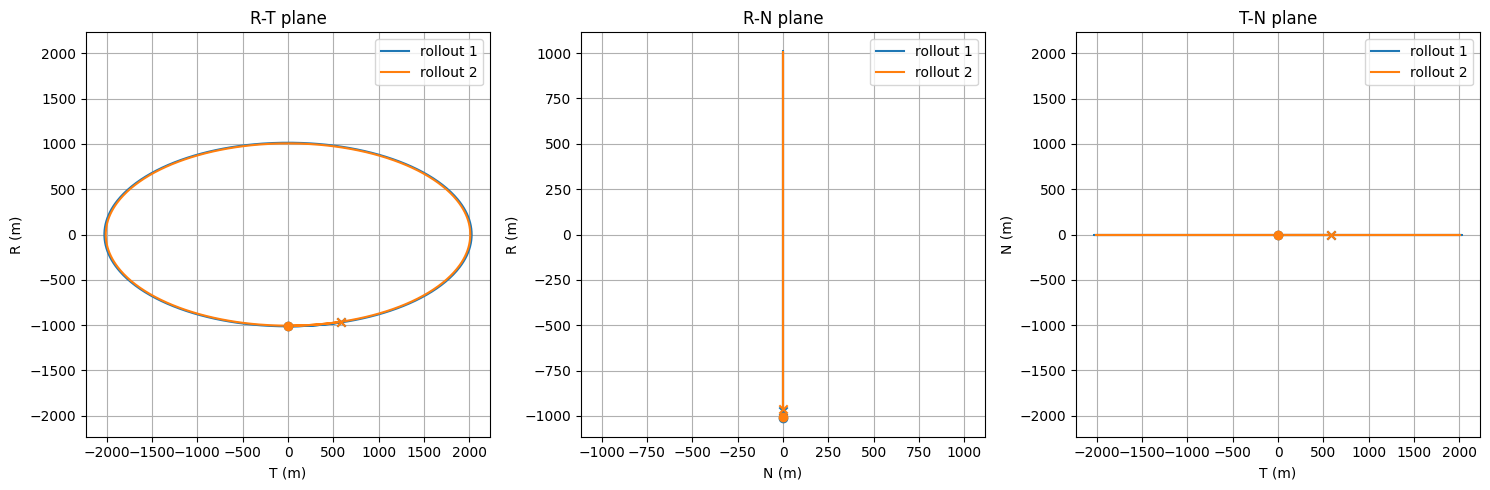

In [6]:
rtn1 = traj1.env_state.guards.rtn  # (T, N=1, 6)
rtn2 = traj2.env_state.guards.rtn

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

plot_rt(rtn1, ax=axes[0], label="rollout 1")
plot_rt(rtn2, ax=axes[0], label="rollout 2")
axes[0].legend(); axes[0].set_title("R-T plane")

plot_rn(rtn1, ax=axes[1], label="rollout 1")
plot_rn(rtn2, ax=axes[1], label="rollout 2")
axes[1].legend(); axes[1].set_title("R-N plane")

plot_tn(rtn1, ax=axes[2], label="rollout 1")
plot_tn(rtn2, ax=axes[2], label="rollout 2")
axes[2].legend(); axes[2].set_title("T-N plane")

fig.tight_layout()
plt.show()

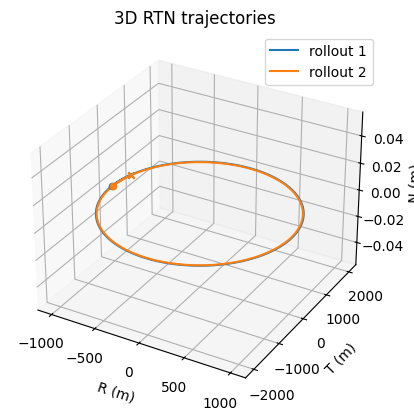

In [7]:
# Full 3D RTN view, both rollouts overlaid (with start/end markers each).
fig3d = plt.figure()
ax3d = fig3d.add_subplot(111, projection="3d")
plot_rtn_3d(rtn1, ax=ax3d, label="rollout 1")
plot_rtn_3d(rtn2, ax=ax3d, label="rollout 2")
ax3d.legend()
ax3d.set_title("3D RTN trajectories")
plt.show()

## 5. Reward curves

Reference reward is `-sum(|guard position|)` per step — the negative 3D distance to the reference orbit. Bigger (less negative) is closer to the reference orbit.

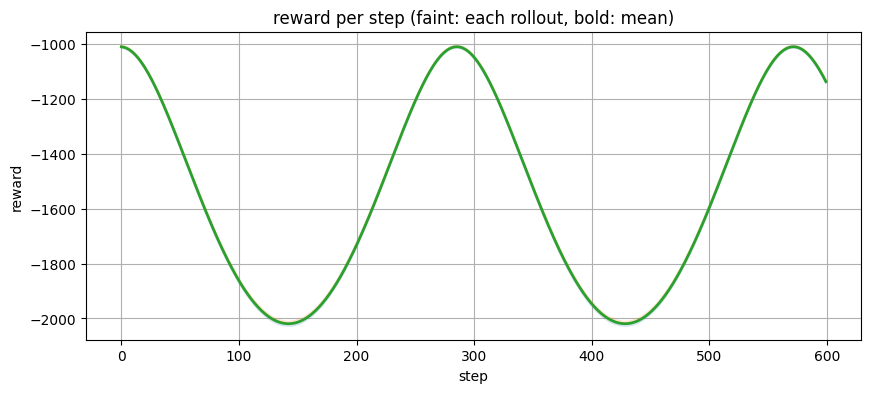

In [8]:
fig, ax = plt.subplots(figsize=(10, 4))
rewards = jnp.stack([traj1.sides.guard.reward, traj2.sides.guard.reward], axis=0)  # (B=2, T)
plot_reward_curve(rewards, ax=ax)
ax.set_title("reward per step (faint: each rollout, bold: mean)")
plt.show()

## 6. Propellant mass over time

Because the guard's `Mass` component is in `guard_components`, the impulsive actuator deposits a rocket-equation Δm into `propellant_mass` each step — but only when the actuator command is non-zero. With the default zero-control policy, propellant stays at its initial 10 kg (flat line). Uncomment the random-impulse policy in section 3 to see propellant deplete.

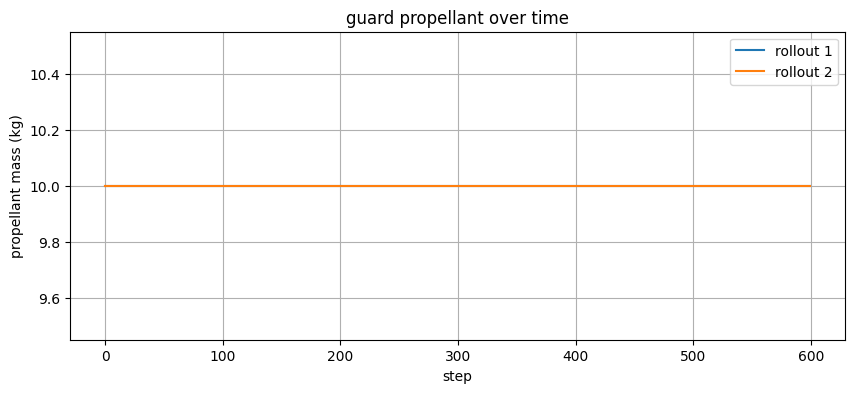

In [9]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(traj1.env_state.guards.propellant_mass[:, 0], label="rollout 1")
ax.plot(traj2.env_state.guards.propellant_mass[:, 0], label="rollout 2")
ax.set_xlabel("step"); ax.set_ylabel("propellant mass (kg)")
ax.set_title("guard propellant over time"); ax.grid(True); ax.legend()
plt.show()

## 7. Persistence — save and reload via HDF5

`save_run(path, config, traj)` writes the rollout to a single HDF5 file with the full scenario config encoded as a JSON root attribute and each trajectory leaf as a gzip-compressed dataset. `load_run(path)` returns `(config, dict[str, jax.Array])` — the trajectory comes back as a flat name-keyed dict (e.g. `"sides.guard.reward"`, `"sides.guard.action"`, `"env_state.guards.rtn"`).

In [10]:
import tempfile, pathlib

tmp = pathlib.Path(tempfile.mkdtemp())
out = tmp / "rollout_1.h5"
save_run(out, cfg, traj1)

loaded_cfg, loaded_traj = load_run(out)

print(f"file written:           {out}  ({out.stat().st_size:,} bytes)")
print(f"loaded config matches:  {loaded_cfg.n_guards == cfg.n_guards and loaded_cfg.dt == cfg.dt}")
print(f"trajectory keys:        {sorted(loaded_traj.keys())[:6]} ...")
print(f"reward round-trips:     {bool(jnp.allclose(loaded_traj['sides.guard.reward'], traj1.sides.guard.reward))}")

file written:           /var/folders/66/25bqc2bn19bb84ddx70zwv9m0000gn/T/tmpjewbbg0a/rollout_1.h5  (156,755 bytes)
loaded config matches:  True
trajectory keys:        ['env_state.bandits.rtn', 'env_state.guards.propellant_mass', 'env_state.guards.rtn', 'env_state.ic_valid', 'env_state.reference_orbit.position_eci', 'env_state.reference_orbit.velocity_eci'] ...
reward round-trips:     True


## 8. Per-rollout multi-actor visualizations + 3D animation

The `viz` module also offers per-rollout views (every guard *and* every
bandit on one figure, color-coded by side) and a configurable 3D
animation system. The animation share a single per-frame renderer between
an interactive `ipywidgets` viewer and an MP4 exporter, with toggleable
layers:

- **`show_cubes`** — translucent cubes for each agent (oriented by
  `Attitude.quat` if the state component is present, identity otherwise)
- **`show_sensor_range`** — translucent grey sphere at each agent showing
  its sensor-range gate; auto-inferred from
  `cfg.guard_observation_fn` / `cfg.bandit_observation_fn` if they are
  `RangeLimitedObservation`
- **`show_thrust`** — Δv arrows in RTN, scaled so the largest maneuver in
  the rollout occupies 1/20 of the largest axis extent
- **`show_belief`** — 2σ position ellipsoids drawn from the EKF belief
  history per (observer, tracked) pair
- **`show_trail`** — fading trail of past positions (truth)

The reward diagnostic plot overlays the *signal driving the reward*
against the recorded reward, so you can confirm by eye that your reward
construction is doing what you intend.


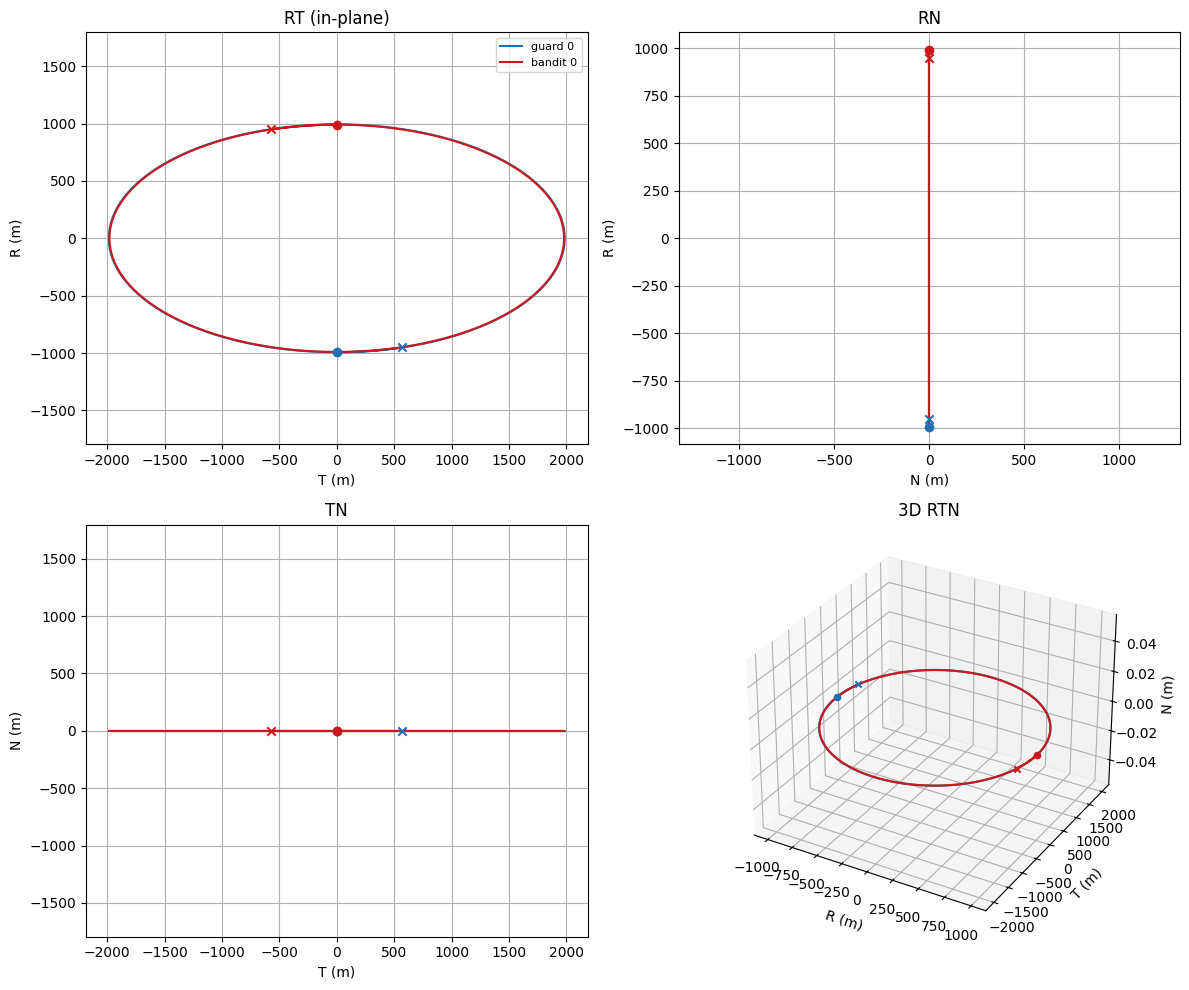

In [11]:
# All actors of one rollout, color-coded by side.
fig = plot_rollout_panels(traj_b)
plt.show()


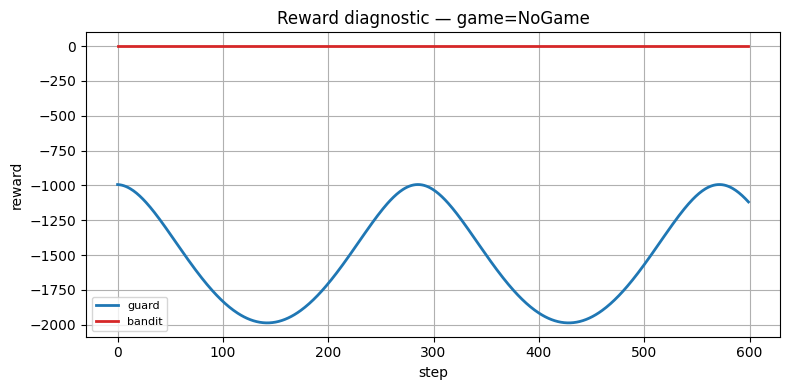

In [12]:
# Reward-construction diagnostic — overlays the signal driving the reward
# against the recorded reward. Game-aware: dispatches per cfg.game type.
fig = plot_reward_diagnostic(traj_b, cfg)
plt.show()


axis limit (m):  2185
n_frames:        600


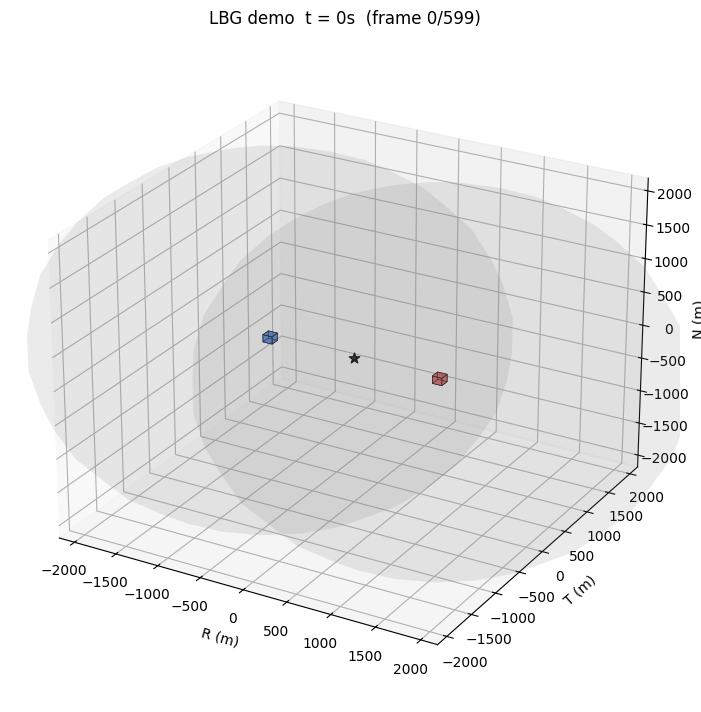

In [13]:
# Build a scene with all toggles enabled. show_sensor_range will be
# auto-inferred from cfg.guard/bandit_observation_fn (RangeLimitedObservation
# → translucent grey sphere at sensor_range_m). show_belief renders 2σ
# position ellipsoids per (observer, tracked) pair from belief_history.
scene = RolloutScene(
    traj=traj_b,
    cfg=cfg,
    dt=cfg.dt,
    show_cubes=True,
    show_trail=True,
    show_sensor_range=True,
    show_thrust=False,        # zero-control rollout: nothing to draw
    show_belief=True,
    belief_history=belief_history,
    title_prefix="LBG demo  ",
)
print(f"axis limit (m):  {scene.axis_limit_m:.0f}")
print(f"n_frames:        {scene.n_frames}")

# Interactive viewer: ipywidgets Play + IntSlider. Works in classic Jupyter
# and JupyterLab; outside those use save_animation below.
fig_anim = interactive_viewer(scene)


In [ ]:
# Save the same scene to MP4. Requires ffmpeg on PATH. Output goes to
# `<repo_root>/outputs/`, which is gitignored.
import shutil, pathlib

def _repo_root() -> pathlib.Path:
    here = pathlib.Path.cwd().resolve()
    for parent in (here, *here.parents):
        if (parent / "pyproject.toml").exists():
            return parent
    return here

if shutil.which("ffmpeg") is not None:
    out_dir = _repo_root() / "outputs"
    out_dir.mkdir(exist_ok=True)
    out_path = out_dir / "rollout_3d_rtn.mp4"
    save_animation(scene, str(out_path), fps=15, dpi=90)
    print(f"saved {out_path}  ({out_path.stat().st_size:,} bytes)")
else:
    print("ffmpeg not available — skipping MP4 export")


## Next steps

What this bootstrap doesn't yet do, and where the real research starts:

- **Real bandit policies** — replace `ZeroControl` with adversarial / cooperative behaviours.
- **Partial-observability observation models** — replace `FullObservation` with masking/noisy variants per side. The guard and bandit already have their own `guard_observation_fn` / `bandit_observation_fn` slots.
- **POMDP planners** — consume `env.layout.flatten(env_state.guards, env_state.bandits)` to get a single flat state vector for belief-space planning.
- **Belief tracking during rollouts** — return a `GaussianBelief` from `init_policy_state_fn` and use it in your policy. The rollout threads it through the scan automatically.
- **Higher-fidelity dynamics** — `astrojax` is wired in as a dep; replace `truth_dynamics` with two-body or full-force propagation while keeping `planning_dynamics = HCW_RTN`.
- **Seed-parallel batches** — `jax.vmap(rollout, in_axes=(None, None, None, 0, None))` over a batch of keys gives you `(B, T, ...)` trajectories with no extra effort.